<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>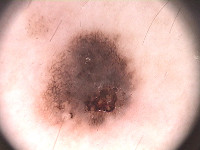</td><td>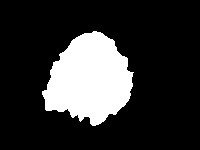</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [2]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=8bba1aca-0d8a-4da1-b6bc-37e771e5fe6b
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 131MB/s]


In [3]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [4]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [5]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [6]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

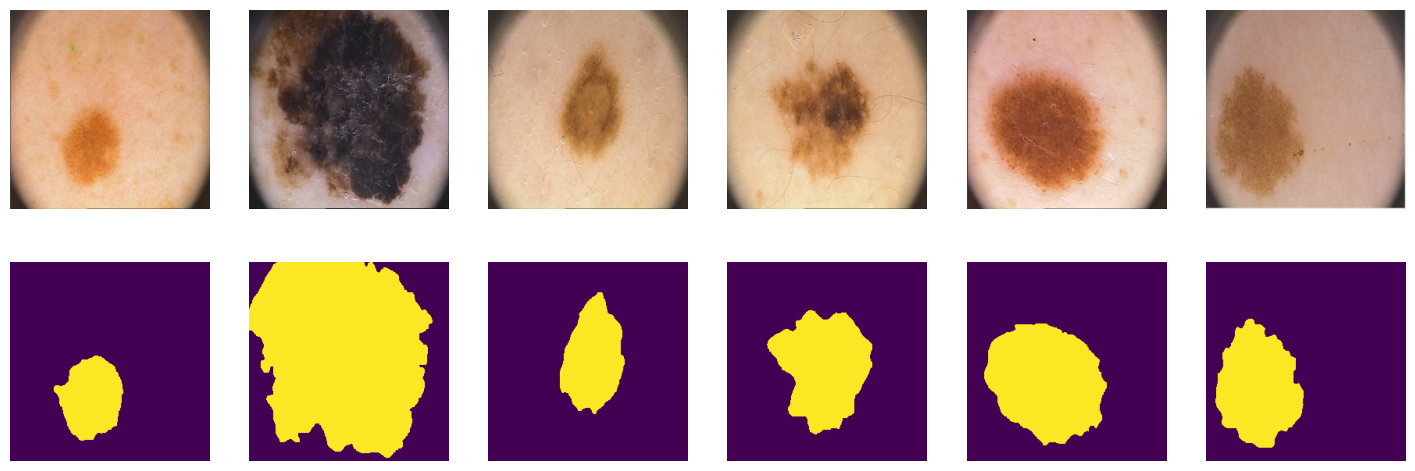

In [7]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [8]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [9]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [10]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [11]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [12]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.6 MB/s eta 0:00:00


In [13]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

Ниже вывод формулы, сразу скажу, выводил на листочке, по сути всё как из документации TensorFlow, но текст LaTex оформляла нейронка(говорю, чтобы не было вопрос по специфики оформления), а теперь к выводу. Собственно мы сразу переходим от суммы к векторам, поэтому исходная формула примет немного другой вид.
\begin{align*}
L(y, \hat{y}) &= -y \log \sigma(\hat{y}) + (-(1-y) \log(1 - \sigma(\hat{y}))) \\
L(y, \hat{y}) &= y \cdot -\log\left( \frac{1}{1+e^{-\hat{y}}} \right) + \left(-(1-y) \log\left( \frac{e^{-\hat{y}}}{1+e^{-\hat{y}}} \right)\right) \\
L(y, \hat{y}) &= y \cdot \log(1+e^{-\hat{y}}) + (1-y)(-\log e^{-\hat{y}} + \log(1+e^{-\hat{y}})) \\
L(y, \hat{y}) &= y \log(1+e^{-\hat{y}}) + (1-y)(\hat{y} + \log(1+e^{-\hat{y}})) = \\
&= \log(1+e^{-\hat{y}})(y + (1-y)) + \hat{y}(1-y) = \hat{y}(1-y) + \log(1+e^{-\hat{y}}) = \\
&= \hat{y} - y\hat{y} + \log(1+e^{-\hat{y}})
\end{align*}
Вторая строка получается, если мы напишем сигмоиду по определению. Строки далее - это свойства логарифмов(логарифм частного и вынесение степени из-под знака логарифма) и определение логарифма.  Отмечу, что для реализации, чтобы избежать переполнения и неустойчивости (для данной формулы может возникнуть проблема, когда x < 0), используют такой вариант: max(x, 0) - x * z + log(1 + exp(-abs(x))), где x - наши логиты, z - таргет.

**Ответ: ЧТД**

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [14]:
import torch.nn.functional as F
import torch.nn as nn

In [15]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [16]:
from math import e


def bce_loss(y_pred, y_real):
  ones = torch.ones_like(y_pred)
  loss = torch.sum(y_pred - y_real * y_pred + torch.log(ones + e ** (-y_pred)))
  return loss

def bce_true(y_pred, y_real):
  ones = torch.ones_like(y_pred) # создаём тензор той же размерности, что и данные, до этого я пробовал задавать 2 размерности, но оказалось,
  # что размерностей может быть много и есть функция, которая сразу позволяет создать аналогичный по размерности тензор
  loss = torch.sum(-y_real * torch.log(torch.sigmoid(y_pred)) - (ones - y_real) * torch.log(ones - torch.sigmoid(y_pred)))
  return loss

Проверим корректность работы на простом примере

In [17]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss             = 4.620283126831055
BCE loss честно посчитанный                = 4.620283126831055
BCE loss from torch bce_torch              = 4.620283126831055
BCE loss from torch with logits bce_torch  = 4.620283126831055


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [18]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [19]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 14.708992004394531
BCE loss честно посчитанный               = 14.708992958068848
BCE loss from torch bce_torch             = 14.708992958068848
BCE loss from torch with logits bce_torch = 14.708992958068848


In [20]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [21]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 5.85MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 7.08MB/s]
Download completed


In [22]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

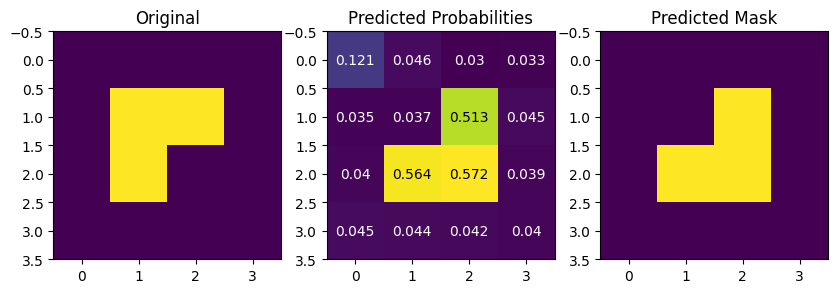

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [24]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

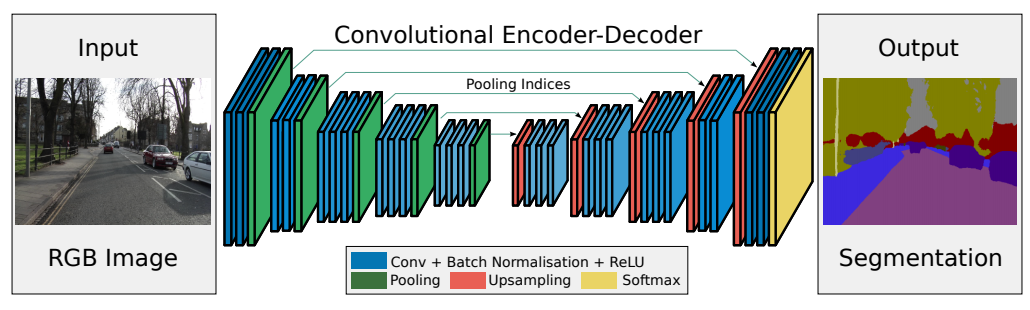

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [26]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 77.4MB/s]


In [27]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [28]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [29]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        self.unpooling = nn.MaxUnpool2d(2, stride=2)
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

  def forward(self, x, indices):
        x = self.unpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [30]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels = 1, num_features = 64) -> None:
        super(SegNet, self).__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)


        # Encoder bottleneck - количество каналов на входе и на выходе одинаково
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder bottleneck
        self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder
        self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder4 = DecoderBlock(num_features, out_channels, depth=2)

    def forward(self, x):
        # encoder
        x, indices0 = self.encoder0(x)
        x, indices1 = self.encoder1(x)
        x, indices2 = self.encoder2(x)
        x, indices3 = self.encoder3(x)
        x, indices4 = self.encoder4(x)
        # decoder
        x = self.decoder0(x, indices4) # здесь мы используем индексы максимальных элементов после MaxPooling в слое блоке Encoder
        x = self.decoder1(x, indices3)
        x = self.decoder2(x, indices2)
        x = self.decoder3(x, indices1)
        output = self.decoder4(x, indices0)

        return output  # no activation

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [31]:
from tqdm.notebook import tqdm
import torch
from torchmetrics import JaccardIndex

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import os

In [32]:
def train_single_epoch(model, optimizer, criterion, train_dataloader, device):
    model.train()

    avg_loss = 0
    for X_batch, Y_batch in tqdm(train_dataloader):
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        Y_pred = torch.sigmoid(model(X_batch))
        loss = criterion(Y_pred, Y_batch) # forward-pass

        loss.backward()  # backward-pass
        optimizer.step()  # update weights
        optimizer.zero_grad() # set parameter gradients to zero

        # calculate loss to show the user
        avg_loss += loss

    avg_loss = avg_loss / len(train_dataloader)

    return model, avg_loss


def validate_single_epoch(model, criterion, valid_dataloader, device):

    iou_score = JaccardIndex(threshold=0.5, task="binary", num_classes=1, average='none').to(device)
    model.eval()

    avg_loss = 0
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in tqdm(valid_dataloader):
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred =  torch.sigmoid(model(X_batch))
          iou = iou_score(Y_pred, Y_batch)
          loss = criterion(Y_pred, Y_batch)
          avg_loss += loss
          avg_iou += iou

    avg_loss = avg_loss / len(valid_dataloader)
    avg_iou = avg_iou / len(valid_dataloader)

    return model, avg_loss, avg_iou

def train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path):

    if not os.path.exists(ckpt_path):
        os.makedirs(ckpt_path) # pytorch по умолчанию просто добавляет файлы в директорию, но перед тем как добавлять, эту директорию нужно создать

    total_train_loss = []
    total_val_loss = []
    total_val_iou = []

    best_val_loss = float('inf')
    best_val_iou = 0

    for epoch in tqdm(range(epochs)):

        model, train_loss = train_single_epoch(model, optimizer, criterion, train_dataloader, device)
        model, val_loss, val_iou = validate_single_epoch(model, criterion, valid_dataloader, device)
        print(f'Epoch {epoch}: train loss = {train_loss}')
        print(f'Epoch {epoch}: val loss = {val_loss}')
        print(f'Epoch {epoch}: val iou = {val_iou}')

        total_train_loss.append(train_loss.cpu().detach().numpy())
        total_val_loss.append(val_loss.cpu().detach().numpy())
        total_val_iou.append(val_iou.cpu().detach().numpy())
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            ckpt_name = f'/epoch_{epoch}_best_val_loss.pt'
            torch.save(model.state_dict(), f'{ckpt_path}/epoch_{epoch}_best_val_loss.pt')

        torch.save(model.state_dict(), f'{ckpt_path}/epoch_{epoch}_val_iou.pt')

    statistics = {'train loss': total_train_loss,
                  'val_loss': total_val_loss,
                  'val_iou': total_val_iou}

    return model, statistics, ckpt_name

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [ ]:
model = SegNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = bce_torch
epochs = 20
ckpt_path = '/content/checkpoints'
model, statictics, ckpt_name = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path)
# Отмечу, что у меня закончился доступ к бесплатному графическому ускорителю, поэтому всё обучение на CPU и очень долгое, это конкретно длилось 2.5 часа

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 0: train loss = 1204544.75
Epoch 0: val loss = 1135652.5
Epoch 0: val iou = 0.0


  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 18: train loss = 1007943.6875
Epoch 18: val loss = 1035398.5
Epoch 18: val iou = 0.536802351474762


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19: train loss = 992725.8125
Epoch 19: val loss = 1063046.125
Epoch 19: val iou = 0.4633227288722992


Видно, что по метрике bce качество у нашей модели не очень хорошее(максимум около 0.6). Как мне кажется, причина в том, что обучение происходило всего на 100 картинках, в отличие например от семинара, где размер датасета был не 200, а 5000.

## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [33]:
def test(model, test_dataloader, device, ckpt_path, ckpt_name):

    model.load_state_dict(torch.load(f'{ckpt_path}/{ckpt_name}'))
    model.to(device)
    model.eval()

    iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in test_dataloader:
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch.to(device))
          avg_iou += iou_score(Y_pred, Y_batch)
      avg_iou = avg_iou / len(test_dataloader)

    return avg_iou

In [ ]:
test(model, test_dataloader, device, ckpt_path, ckpt_name)

tensor(0.6085)

Насколько я знаю ниже 0.5 уже не хорошо, а 0.6 неплохо, особенно при маленьком количестве данных

In [ ]:
# import shutil
# import os

# folder_path = '/content/checkpoints'

# # Проверяем, существует ли папка, чтобы избежать ошибки, если её уже нет
# if os.path.exists(folder_path):
#     shutil.rmtree(folder_path)
#     print(f"Папка '{folder_path}' и всё её содержимое успешно удалены.")
# else:
#     print(f"Папка '{folder_path}' не найдена.")

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [34]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    probabilities = torch.sigmoid(logits)
    pred_mask = (probabilities > threshold).float()
    labels = labels.float()
    tp = torch.sum(pred_mask * labels)
    fp = torch.sum(pred_mask) - tp
    fn = torch.sum(labels) - tp
    # Здесь всё довольно стандартно, находим true positive, false positive и false negative
    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return score

Проверим на корректность функцию dice_score:

In [35]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(num_classes=1, average='macro').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.3158, device='cuda:0')

In [36]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

"\nесли вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():\n\nfrom torchmetrics.classification import Dice\n\ndice = Dice(average='micro').to(device)\n\n"

In [37]:
dice_score(dummpy_sample['logits'], dummpy_sample['labels'].to(int))

tensor(0.6667, device='cuda:0')

In [147]:
# assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [38]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
  probabilities = logits.sigmoid()
  tp = torch.sum(probabilities * labels)
  fp = torch.sum(probabilities) - tp
  fn = torch.sum(labels) - tp
  eps = 1e-8
  score = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  loss = 1 - score
  return loss


Проверка на корректность:

In [39]:
# проверьте, что у вас установлена библиотека
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.1 MB/s eta 0:00:00


In [40]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [41]:
dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [42]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

У меня сошёлся Loss с segmentation_models_pytorch, но score вообще не сходится, как это ни странно(я пробовал совершенно разные варианты, но как мне показалось, моя реализация правильная, я отдельно её тестировал и по идее мой dice score полностью посчитать по приведённой выше идее)

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [43]:
from math import e
from torch import log

def focal_loss(y_real, y_pred, eps = 1e-8, gamma = 2):
    loss = -pow((1 - (torch.sigmoid(y_pred) * y_real + (1 - torch.sigmoid(y_pred)) * (1 - y_real))), gamma) * (y_real * log(torch.sigmoid(y_pred) + eps) + (1 - y_real) * log(1 - torch.sigmoid(y_pred) + eps))

    return torch.sum(loss)

Проверка корректности функции:

In [44]:
from torchvision.ops import sigmoid_focal_loss

torch_var = sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum').item()

In [45]:
my_var = focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0).item()
print(torch_var, my_var)

3.616123676300049 3.616123676300049


Видно, что значения различаются, но не сильно, я считаю их эквивалентными, так как при подсчёте есть определённая погрешность и в данном случае сравнивать вещественные числа не совсем корректно(на мой взгляд)

In [146]:
# assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

Возникает ошибка, её я описал выше

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

**Boundary loss for highly unbalanced segmentation**

In [53]:
# Общая идея очень кратко: Для сильно несбалансированной сегментации dice и bce неэффективны,
# так как считают ошибку по всей поверхности, а здесь мы будем считать ошибку только по границам(насколько я понял из статьи)

class BoundaryLoss ():
    def __call__(self, probs, dist_maps):
        pc = probs[:, self.idc, ...].type(torch.float32)
        dc = dist_maps[:, self.idc, ...].type(torch.float32)

        multipled = pc * dc

        loss = multipled.mean()

        return loss
# Эту реализацию BoundaryLoss я взял с их GitHub, вот ссылочка: https://github.com/LIVIAETS/boundary-loss
# Значит тут мы поэлементно умножаем тензор вероятностей на тензор карт расстояний(эти карты расстояний заранее должны быть предпосчитаны, расстояний здесь от точки до ближайшей границы объекта), а затем просто берём среднее.
# В GitHub у них ещё разные проверки, я их для простоты убрал и умножение у них реализовано через такую строчку: einsum("bkwh,bkwh->bkwh", pc, dc) для перемножения с указанием размерностей тензора,
# В общем эта штука может одновременно умножить матрицы, а затем ещё сложить, она из numpy

**Tversky loss function for image segmentation using 3D fully convolutional deep networks**

In [55]:
# Идея: также боремся с несбалансированностью, recall для классификации будет очень важен, особенно в медицинских данных, вводим дополнительные коэффициента в формуле для Dice Loss
import torch
import torch.nn as nn

def Tversky_index(logits: torch.Tensor, labels: torch.Tensor, a, b , c):
    probabilities = logits.sigmoid()
    tp = torch.sum(probabilities * labels)
    fp = torch.sum(probabilities) - tp
    fn = torch.sum(labels) - tp # Вычисления полностью аналогичны с DiceLoss
    tversky_index = (tp + c) / (tp + a * fp + b * fn + c) # главные изменения с коэффициентами здесь
    return 1 - tversky_index

**Correlation Maximized Structural Similarity Loss for Semantic Segmentation**

In [ ]:
# Подход: Помогает хранить структурную информацию об объектах, потому что в случае с лоссом по пикселям теряется структурная информация об объекте
# Использует линейную корреляцию между двумя изображениями для количественной оценки их структурного сходства
# Открытой реализации, к сожалению, не нашёл, так как имплементации нет, баллы можете спокойно не ставить за этот пункт, просто самому было интересно разобраться

## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



Обучение модели с помощью focal_loss

In [50]:
model = SegNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = focal_loss
epochs = 20
ckpt_path = '/content/checkpoints2'
model, statictics, ckpt_name = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 0: train loss = 270671.03125
Epoch 0: val loss = 288647.6875
Epoch 0: val iou = 0.3103756606578827


  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 18: train loss = 228562.625
Epoch 18: val loss = 235206.75
Epoch 18: val iou = 0.7292929887771606


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19: train loss = 229153.25
Epoch 19: val loss = 233149.875
Epoch 19: val iou = 0.7170230150222778


Тестирование с focal_losss

In [51]:
test(model, test_dataloader, device, ckpt_path, ckpt_name)

tensor(0.6784, device='cuda:0')

Обучение с dice_loss

In [48]:
model = SegNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = dice_loss
epochs = 20
ckpt_path = '/content/checkpoints3'
model, statictics, ckpt_name = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 0: train loss = 0.5556440353393555
Epoch 0: val loss = 0.5841312408447266
Epoch 0: val iou = 0.3103756606578827


  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 18: train loss = 0.5310344099998474
Epoch 18: val loss = 0.5595775246620178
Epoch 18: val iou = 0.6931078433990479


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 19: train loss = 0.5309406518936157
Epoch 19: val loss = 0.5599986910820007
Epoch 19: val iou = 0.7221428751945496


Тестирование с dice_loss

In [49]:
test(model, test_dataloader, device, ckpt_path, ckpt_name)

tensor(0.7701, device='cuda:0')

**Выводы и комментарий:** Наилучшее качество по метрике iou было достигнуто с применением dice_loss, на тесте 0.77, что я считаю прекрасным результатом для данной задачи! Отмечу также, что оба варианта (dice_loss и focal_loss) превзошли обычный вариант с бинарной кросс энтропией(с её помощью я обучал нейросеть в самом начале), что логично, так как они оба являются своеобразными апгрейдам BCE. Если говорить о сходимости, то вероятнее быстрее сошёлся focal_loss, по крайней мере его значения метрики приближались к итоговым где-то с 7-ой - 8-ой эпох, в то время как у dice_loss где-то с 11-ой эпохи, а у BCE качество довольно сильно изменялось, в итоге стало вообще 0.48 на последней эпохе, поэтому здесь довольно сложно судить о сходимости.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

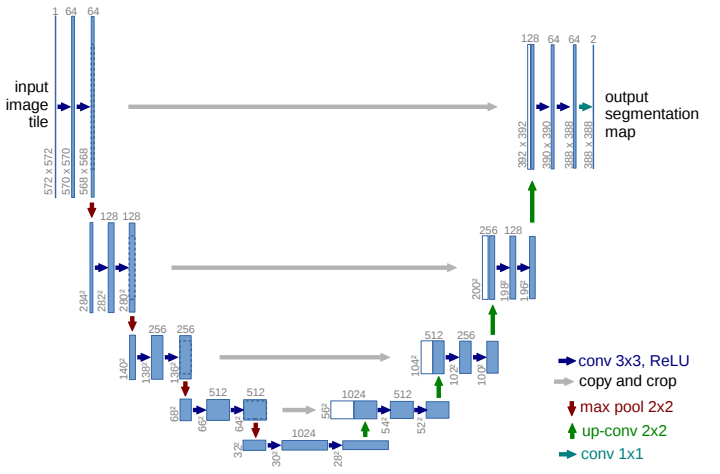

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [148]:
import torch.nn.functional as F
import torch.nn as nn

In [ ]:
class EncoderBlockUnet(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(depth):
            self.layers.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


class DecoderBlockUnet(nn.Module):
  def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(DecoderBlock, self).__init__()
        self.layers = nn.ModuleList()
        self.up_conv = nn.MaxUnpool2d(2, stride=2)
        for i in range(depth):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.ReLU(inplace=True))


  def forward(self, x, indices):
        x = self.unpooling(x, indices)
        for layer in self.layers:
            x = layer(x)
        return x

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

Это лишь примерная реализация без skip connection слоёв(не совсем понял, как их сделать). Я заметил, что в каждом блоке у нас 3 слоя, поэтому можно проходиться только одним циклом, в целом это задание я, к сожалению не успел и не до конца разобраться, поэтому можете ничего здесь не смотреть, надеюсь в ближайшем будущем разбирусь со всем.

In [ ]:
# class UNet(nn.Module):
#     def __init__(self, n_class=1):
#         super().__init__()
#         # Encoder
#         self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
#         self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
#         self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
#         self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)


#         # Encoder bottleneck - количество каналов на входе и на выходе одинаково
#         self.encoder4 = EncoderBlock(num_features * 8, num_features * 8, depth=3)
#         self.bottleneck = nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding)
#         # Decoder bottleneck
#         self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

#         self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
#         self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
#         self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
#         self.decoder4 = DecoderBlock(num_features, out_channels, depth=2)

#     def forward(self, x):
#         # encoder
#         x, indices0 = self.encoder0(x)
#         x, indices1 = self.encoder1(x)
#         x, indices2 = self.encoder2(x)
#         x, indices3 = self.encoder3(x)
#         x, indices4 = self.encoder4(x)
#         # decoder
#         x = self.decoder0(x, indices4)
#         x = self.decoder1(x, indices3)
#         x = self.decoder2(x, indices2)
#         x = self.decoder3(x, indices1)
#         output = self.decoder4(x, indices0)

#         return output  # no activation

In [ ]:
# unet_model = UNet().to(device)

## Обучите UNet

In [ ]:
# model_unet = SegNet().to(device)
# optimizer_unet = torch.optim.Adam(model.parameters(), lr=1e-3)
# criterion = bce_torch
# epochs = 20
# ckpt_path = '/content/checkpoints/2'
# model, statictics, ckpt_name = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path)

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



**Итоговые вводы** несмотря на то, что я не сделал это задание оставлю небольшие комментарии. Значит я почитал, оказалось, что Unet и SegNet можно использовать для разных задач и оба они по своему хороши, но Unet обучается быстрее и её специализация именно мелкие данные(чаще всего медицинские) и выигрывает, когда данных в целом мало, поэтому на данном датасете скорее всего покажет себя лучше. Однако SegNet экономичнее по потребляемой видеопамяти.